# Chirp test
I test chirp to see how they behave by doing correlation to find starting time and from the received signal, I compared it using different graphs such as 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd

from scipy.io.wavfile import write
from scipy.signal import chirp, welch, spectrogram, correlate, correlation_lags

print("sounddevice imported successfully")
print(sd.query_devices())

sounddevice imported successfully
   0 Microsoft 声音映射器 - Input, MME (2 in, 0 out)
>  1 麦克风阵列 (适用于数字麦克风的英特尔® 智音技术), MME (6 in, 0 out)
   2 Microsoft 声音映射器 - Output, MME (0 in, 2 out)
<  3 扬声器 (Realtek(R) Audio), MME (0 in, 2 out)
   4 主声音捕获驱动程序, Windows DirectSound (2 in, 0 out)
   5 麦克风阵列 (适用于数字麦克风的英特尔® 智音技术), Windows DirectSound (6 in, 0 out)
   6 主声音驱动程序, Windows DirectSound (0 in, 2 out)
   7 扬声器 (Realtek(R) Audio), Windows DirectSound (0 in, 2 out)
   8 扬声器 (Realtek(R) Audio), Windows WASAPI (0 in, 2 out)
   9 麦克风阵列 (适用于数字麦克风的英特尔® 智音技术), Windows WASAPI (4 in, 0 out)
  10 立体声混音 (Realtek HD Audio Stereo input), Windows WDM-KS (2 in, 0 out)
  11 Headphones 1 (Realtek HD Audio 2nd output with SST), Windows WDM-KS (0 in, 2 out)
  12 Headphones 2 (Realtek HD Audio 2nd output with SST), Windows WDM-KS (0 in, 2 out)
  13 电脑扬声器 (Realtek HD Audio 2nd output with SST), Windows WDM-KS (2 in, 0 out)
  14 麦克风 1 (Realtek HD Audio Mic input with SST), Windows WDM-KS (2 in, 0 out)
  15 麦克风 2 (Realt

In [2]:
fs = 48000
T_chirp = 0.5
f0 = 500
f1 = 8000
amp = 0.3

t = np.arange(int(T_chirp * fs)) / fs

up_chirp = chirp(t, f0=f0, f1=f1, t1=T_chirp, method="linear")
down_chirp = chirp(t, f0=f1, f1=f0, t1=T_chirp, method="linear")

window = np.hanning(len(t))
up_chirp = amp * up_chirp * window
down_chirp = amp * down_chirp * window

silence_1s = np.zeros(int(1.0 * fs))
silence_02s = np.zeros(int(0.2 * fs))

tx = np.concatenate([
    silence_1s,
    up_chirp,
    silence_02s,
    down_chirp,
    silence_1s
])

write("chirp_test_tx.wav", fs, tx.astype(np.float32))

print("Saved chirp_test_tx.wav")
print("Duration:", len(tx) / fs, "seconds")

Saved chirp_test_tx.wav
Duration: 3.2 seconds


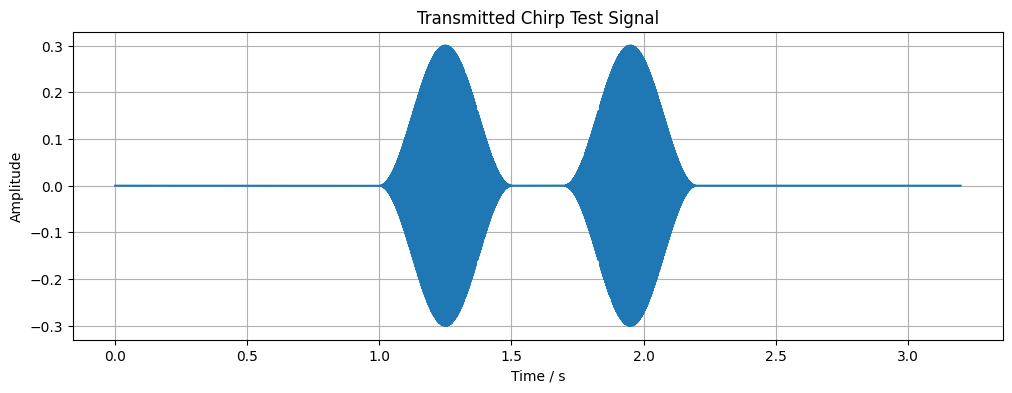

In [3]:
time_tx = np.arange(len(tx)) / fs

plt.figure(figsize=(12, 4))
plt.plot(time_tx, tx)
plt.xlabel("Time / s")
plt.ylabel("Amplitude")
plt.title("Transmitted Chirp Test Signal")
plt.grid(True)
plt.show()

In [9]:
fs_rx = 48000
record_seconds = 5.0

print("Recording started.")
print("Play chirp_test_tx.wav now.")

rx = sd.rec(
    int(record_seconds * fs_rx),
    samplerate=fs_rx,
    channels=1,
    dtype="float32"
)

sd.wait()

rx = rx[:, 0]

write("chirp_test_rx.wav", fs_rx, rx.astype(np.float32))

print("Recording finished.")
print("Saved chirp_test_rx.wav")
print("Max amplitude:", np.max(np.abs(rx)))
print("Duration:", len(rx) / fs_rx, "seconds")

Recording started.
Play chirp_test_tx.wav now.
Recording finished.
Saved chirp_test_rx.wav
Max amplitude: 0.2616272
Duration: 5.0 seconds


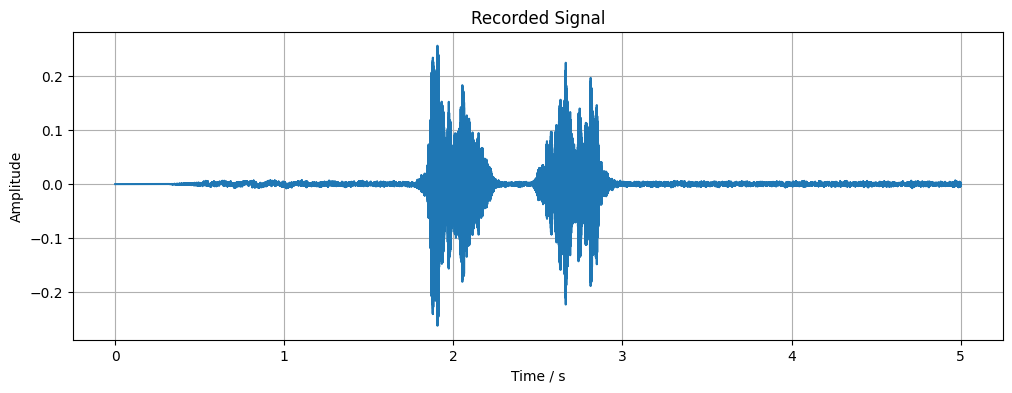

In [10]:
time_rx = np.arange(len(rx)) / fs_rx

plt.figure(figsize=(12, 4))
plt.plot(time_rx, rx)
plt.xlabel("Time / s")
plt.ylabel("Amplitude")
plt.title("Recorded Signal")
plt.grid(True)
plt.show()

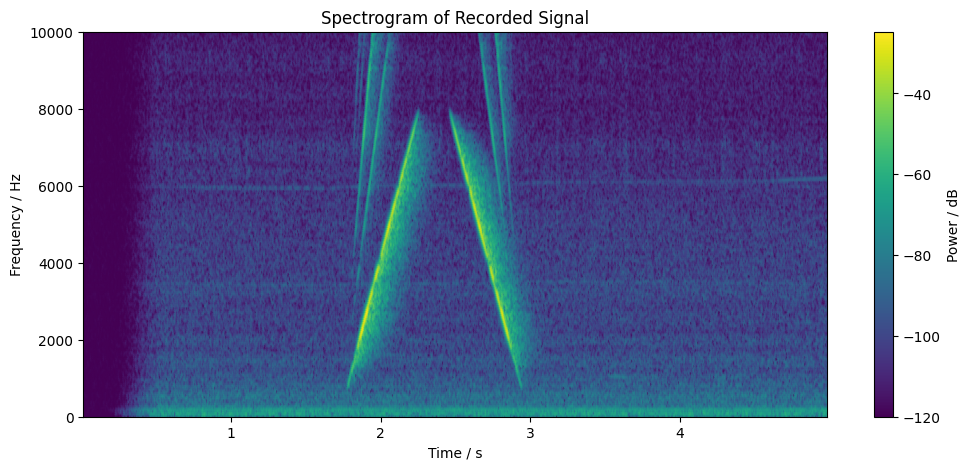

In [11]:

rx_proc = rx - np.mean(rx)
rx_proc = rx_proc / (np.max(np.abs(rx_proc)) + 1e-12)

f_spec, t_spec, Sxx = spectrogram(
    rx_proc,
    fs=fs_rx,
    window="hann",
    nperseg=1024,
    noverlap=768
)

Sxx_dB = 10 * np.log10(Sxx + 1e-12)

plt.figure(figsize=(12, 5))
plt.pcolormesh(t_spec, f_spec, Sxx_dB, shading="gouraud")
plt.ylim(0, 10000)
plt.xlabel("Time / s")
plt.ylabel("Frequency / Hz")
plt.title("Spectrogram of Recorded Signal")
plt.colorbar(label="Power / dB")
plt.show()

Up-chirp detected time: 1.7600208333333334
Down-chirp detected time: 2.46
Detected spacing: 0.6999791666666666
Expected spacing: 0.7


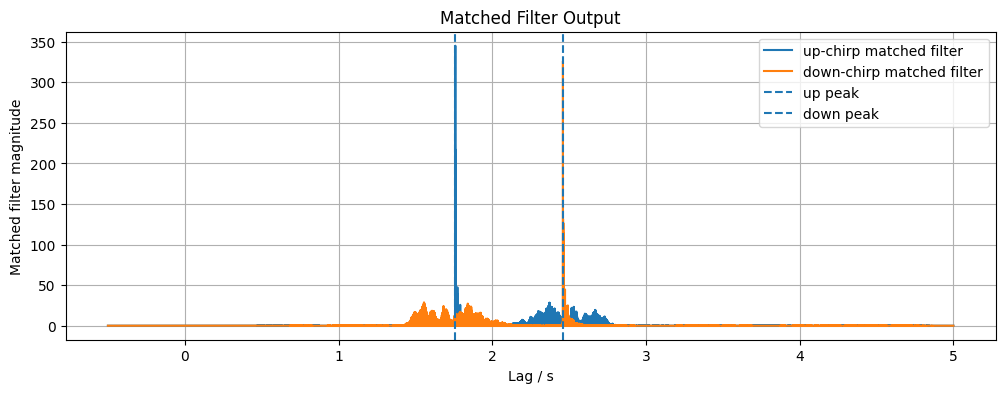

In [12]:
# match filter
from scipy.signal import chirp, correlate, correlation_lags

T_chirp = 0.5
f0 = 500
f1 = 8000
amp = 0.3

def generate_reference_chirps(fs, T_chirp=0.5, f0=500, f1=8000, amp=0.3):
    t = np.arange(int(T_chirp * fs)) / fs

    up = chirp(t, f0=f0, f1=f1, t1=T_chirp, method="linear")
    down = chirp(t, f0=f1, f1=f0, t1=T_chirp, method="linear")

    window = np.hanning(len(t))
    up = amp * up * window
    down = amp * down * window

    return up, down

up_ref, down_ref = generate_reference_chirps(fs_rx, T_chirp, f0, f1, amp)

rx_proc = rx - np.mean(rx)
rx_proc = rx_proc / (np.max(np.abs(rx_proc)) + 1e-12)

corr_up = correlate(rx_proc, up_ref, mode="full")
lags_up = correlation_lags(len(rx_proc), len(up_ref), mode="full")
mag_up = np.abs(corr_up)

corr_down = correlate(rx_proc, down_ref, mode="full")
lags_down = correlation_lags(len(rx_proc), len(down_ref), mode="full")
mag_down = np.abs(corr_down)

peak_lag_up = lags_up[np.argmax(mag_up)]
peak_time_up = peak_lag_up / fs_rx

peak_lag_down = lags_down[np.argmax(mag_down)]
peak_time_down = peak_lag_down / fs_rx

print("Up-chirp detected time:", peak_time_up)
print("Down-chirp detected time:", peak_time_down)
print("Detected spacing:", peak_time_down - peak_time_up)
print("Expected spacing:", T_chirp + 0.2)

plt.figure(figsize=(12, 4))
plt.plot(lags_up / fs_rx, mag_up, label="up-chirp matched filter")
plt.plot(lags_down / fs_rx, mag_down, label="down-chirp matched filter")
plt.axvline(peak_time_up, linestyle="--", label="up peak")
plt.axvline(peak_time_down, linestyle="--", label="down peak")
plt.xlabel("Lag / s")
plt.ylabel("Matched filter magnitude")
plt.title("Matched Filter Output")
plt.legend()
plt.grid(True)
plt.show()

The chirp receiver test successfully detected both the up-chirp and down-chirp using matched filtering. The detected time separation between the two chirps was 0.69998 s, compared with the expected 0.70000 s, corresponding to an error of approximately one sample at 48 kHz. This confirms that the receiver can reliably detect the chirp preamble and estimate timing with sample-level accuracy under the tested acoustic setup


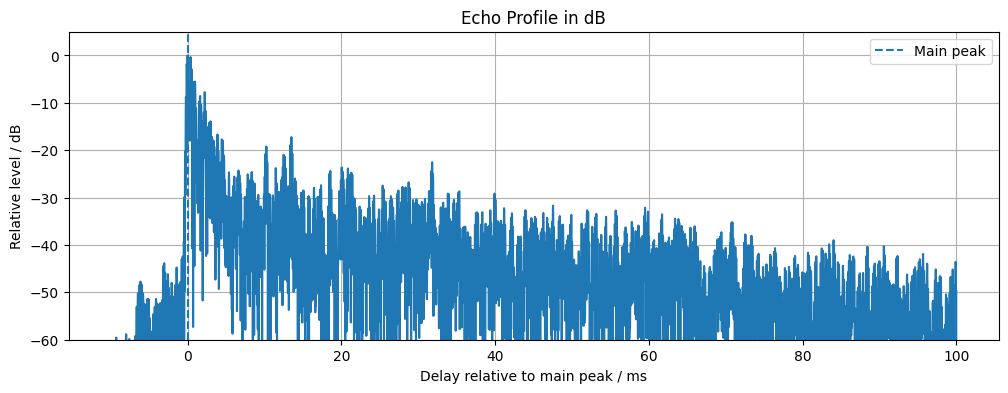

In [14]:
# Analyze echoes around the up-chirp peak
pre_ms = 10
post_ms = 100

pre_samples = int(pre_ms / 1000 * fs_rx)
post_samples = int(post_ms / 1000 * fs_rx)

mask = (lags_up >= peak_lag_up - pre_samples) & (lags_up <= peak_lag_up + post_samples)

relative_time_ms = (lags_up[mask] - peak_lag_up) / fs_rx * 1000
echo_mag = mag_up[mask]
echo_mag_norm = echo_mag / (np.max(echo_mag) + 1e-12)
echo_mag_db = 20 * np.log10(echo_mag_norm + 1e-12)

plt.figure(figsize=(12, 4))
plt.plot(relative_time_ms, echo_mag_db)
plt.axvline(0, linestyle="--", label="Main peak")
plt.ylim(-60, 5)
plt.xlabel("Delay relative to main peak / ms")
plt.ylabel("Relative level / dB")
plt.title("Echo Profile in dB")
plt.legend()
plt.grid(True)
plt.show()

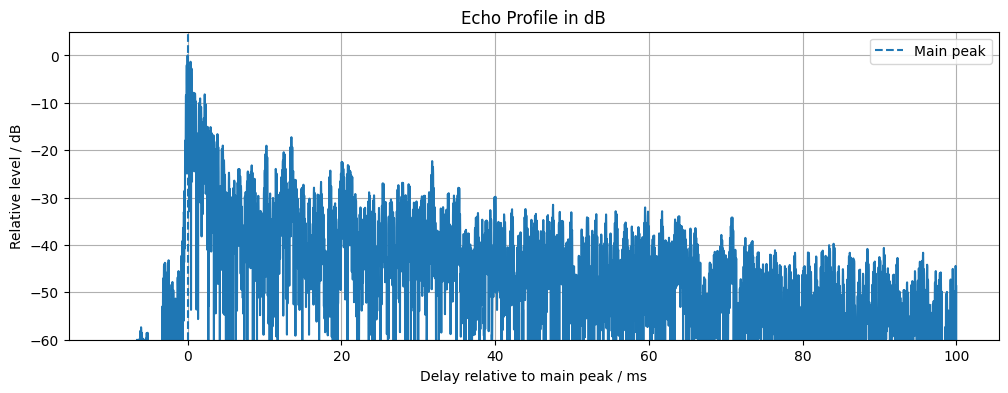

In [16]:
# Analyze echoes around the down-chirp peak
mask = (lags_down >= peak_lag_down - pre_samples) & (lags_down <= peak_lag_down + post_samples)

relative_time_ms = (lags_down[mask] - peak_lag_down) / fs_rx * 1000
echo_mag = mag_down[mask]
echo_mag_norm = echo_mag / (np.max(echo_mag) + 1e-12)
echo_mag_db = 20 * np.log10(echo_mag_norm + 1e-12)

plt.figure(figsize=(12, 4))
plt.plot(relative_time_ms, echo_mag_db)
plt.axvline(0, linestyle="--", label="Main peak")
plt.ylim(-60, 5)
plt.xlabel("Delay relative to main peak / ms")
plt.ylabel("Relative level / dB")
plt.title("Echo Profile in dB")
plt.legend()
plt.grid(True)

For my room, the matched filter successfully detected main peak, but echo is relatively strong. The echo profile shows a clear main peak at 0 ms, corresponding to the direct acoustic path. Several early reflections are visible within the first 5 ms and remain relatively strong, around -10 to -20 dB. Additional multipath components extend up to around 30–40 ms, after which the response gradually decays towards the noise floor. This indicates a moderately reverberant acoustic channel, where early reflections may affect synchronisation and OFDM demodulation unless the cyclic prefix or equalisation is sufficiently robust.

In [17]:
def crop_segment(x, fs, start_time, duration):
    start = int(start_time * fs)
    end = int((start_time + duration) * fs)
    start = max(start, 0)
    end = min(end, len(x))
    return x[start:end]

# Use processed recording
rx_proc = rx - np.mean(rx)
rx_proc = rx_proc / (np.max(np.abs(rx_proc)) + 1e-12)

up_rx = crop_segment(rx_proc, fs_rx, peak_time_up, T_chirp)
down_rx = crop_segment(rx_proc, fs_rx, peak_time_down, T_chirp)

# Noise segment before up-chirp, for example 0.5 s before the detected up-chirp
noise_rx = crop_segment(rx_proc, fs_rx, max(0, peak_time_up - 0.7), 0.5)

print("up segment duration:", len(up_rx) / fs_rx)
print("down segment duration:", len(down_rx) / fs_rx)
print("noise segment duration:", len(noise_rx) / fs_rx)

up segment duration: 0.5
down segment duration: 0.5
noise segment duration: 0.5


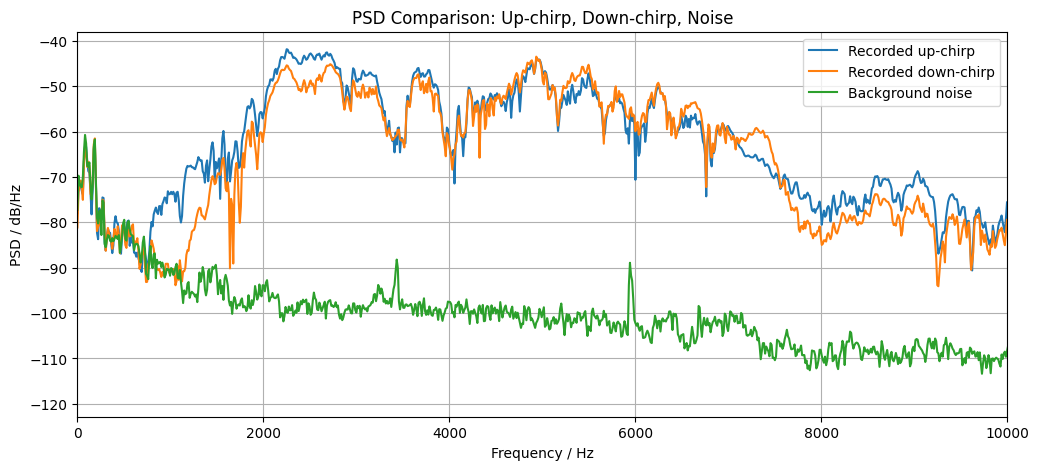

In [18]:
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt

def compute_psd_db(x, fs, nperseg=4096):
    nperseg = min(nperseg, len(x))
    f, Pxx = welch(
        x,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=nperseg // 2,
        scaling="density"
    )
    Pxx_dB = 10 * np.log10(Pxx + 1e-12)
    return f, Pxx_dB, Pxx

f_up, up_db, up_Pxx = compute_psd_db(up_rx, fs_rx)
f_down, down_db, down_Pxx = compute_psd_db(down_rx, fs_rx)
f_noise, noise_db, noise_Pxx = compute_psd_db(noise_rx, fs_rx)

plt.figure(figsize=(12, 5))
plt.plot(f_up, up_db, label="Recorded up-chirp")
plt.plot(f_down, down_db, label="Recorded down-chirp")
plt.plot(f_noise, noise_db, label="Background noise")
plt.xlim(0, 10000)
plt.xlabel("Frequency / Hz")
plt.ylabel("PSD / dB/Hz")
plt.title("PSD Comparison: Up-chirp, Down-chirp, Noise")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
def band_power(f, Pxx, f_low, f_high):
    mask = (f >= f_low) & (f <= f_high)
    return np.trapezoid(Pxx[mask], f[mask])

f_low = 500
f_high = 8000

up_band_power = band_power(f_up, up_Pxx, f_low, f_high)
down_band_power = band_power(f_down, down_Pxx, f_low, f_high)
noise_band_power = band_power(f_noise, noise_Pxx, f_low, f_high)

up_snr_db = 10 * np.log10(up_band_power / (noise_band_power + 1e-12))
down_snr_db = 10 * np.log10(down_band_power / (noise_band_power + 1e-12))

print("Up-chirp band power:", up_band_power)
print("Down-chirp band power:", down_band_power)
print("Noise band power:", noise_band_power)
print("Up-chirp band SNR:", up_snr_db, "dB")
print("Down-chirp band SNR:", down_snr_db, "dB")

Up-chirp band power: 0.06119474736165638
Down-chirp band power: 0.042635387595948024
Noise band power: 2.4039063206711652e-06
Up-chirp band SNR: 44.05796426140157 dB
Down-chirp band SNR: 42.48852495455226 dB


In [21]:
bands = [
    (500, 1000),
    (1000, 2000),
    (2000, 4000),
    (4000, 6000),
    (6000, 8000)
]

print("Band power comparison:")
for low, high in bands:
    up_bp = band_power(f_up, up_Pxx, low, high)
    down_bp = band_power(f_down, down_Pxx, low, high)
    noise_bp = band_power(f_noise, noise_Pxx, low, high)

    up_snr = 10 * np.log10(up_bp / (noise_bp + 1e-12))
    down_snr = 10 * np.log10(down_bp / (noise_bp + 1e-12))

    print(f"{low}-{high} Hz:")
    print(f"  up SNR   = {up_snr:.2f} dB")
    print(f"  down SNR = {down_snr:.2f} dB")

Band power comparison:
500-1000 Hz:
  up SNR   = 6.46 dB
  down SNR = -0.31 dB
1000-2000 Hz:
  up SNR   = 32.50 dB
  down SNR = 26.66 dB
2000-4000 Hz:
  up SNR   = 50.86 dB
  down SNR = 47.48 dB
4000-6000 Hz:
  up SNR   = 48.82 dB
  down SNR = 49.83 dB
6000-8000 Hz:
  up SNR   = 44.64 dB
  down SNR = 45.98 dB


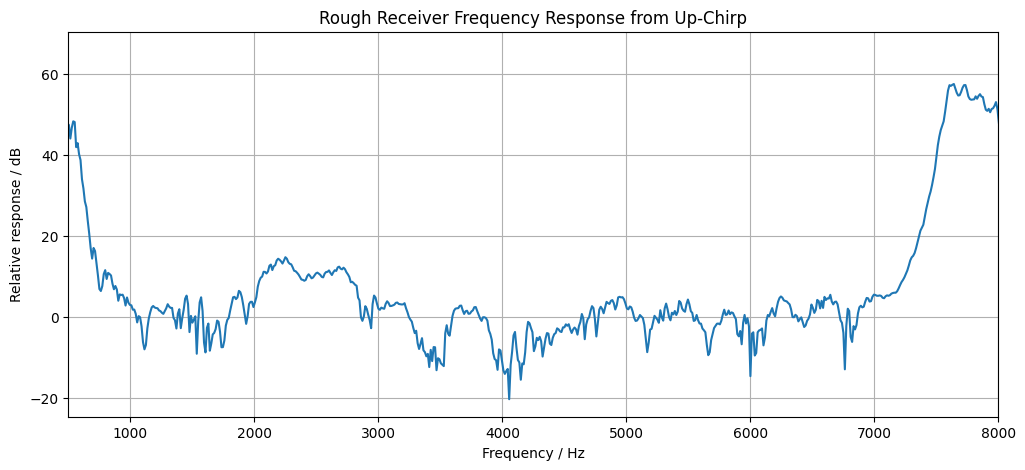

In [22]:
# Generate reference up chirp
from scipy.signal import chirp

t_ref = np.arange(int(T_chirp * fs_rx)) / fs_rx
up_ref = chirp(t_ref, f0=500, f1=8000, t1=T_chirp, method="linear")
up_ref = up_ref * np.hanning(len(up_ref))

f_ref, ref_db, ref_Pxx = compute_psd_db(up_ref, fs_rx)

# Interpolate reference PSD onto recorded frequency axis
ref_db_interp = np.interp(f_up, f_ref, ref_db)

# Rough channel response estimate
H_db = up_db - ref_db_interp

# Remove arbitrary offset by normalising around 1–2 kHz
norm_mask = (f_up >= 1000) & (f_up <= 2000)
H_db_norm = H_db - np.mean(H_db[norm_mask])

plt.figure(figsize=(12, 5))
plt.plot(f_up, H_db_norm)
plt.xlim(500, 8000)
plt.xlabel("Frequency / Hz")
plt.ylabel("Relative response / dB")
plt.title("Rough Receiver Frequency Response from Up-Chirp")
plt.grid(True)
plt.show()